## Facebook Network Analysis

This notebook analyses a Facebook social network dataset using NetworkX.

### I will Load dataset i intend using here first
The Facebook dataset is loaded and converted into a network graph for analysis.

In [62]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [63]:
os.makedirs("outputs", exist_ok=True)

### here we do Data preparation and graph construction
The dataset is extracted and converted into a network graph for analysis porpose

In [64]:
import gzip
import shutil

with gzip.open("facebook_combined.txt.gz", "rb") as f_in:
    with open("facebook_combined.txt", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

fb_graph = nx.read_edgelist("facebook_combined.txt", nodetype=int)


#### We do the Basic network properties
This section reports the size and density of the Facebook network.

In [65]:
n = fb_graph.number_of_nodes()
m = fb_graph.number_of_edges()
density = nx.density(fb_graph)

print("Nodes:", n)
print("Edges:", m)
print("Directed:", fb_graph.is_directed())
print("Density:", round(density, 6))

Nodes: 4039
Edges: 88234
Directed: False
Density: 0.01082


#### The Connected Components Analysis
This section we examines whether the network is fully connected and identifies its largest connected component.

In [66]:
is_connected = nx.is_connected(fb_graph)
components = list(nx.connected_components(fb_graph))
largest_cc = max(components, key=len)
G_lcc = fb_graph.subgraph(largest_cc).copy()

print("Is graph connected:", is_connected)
print("Number of components:", len(components))
print("Largest component nodes:", G_lcc.number_of_nodes())
print("Largest component edges:", G_lcc.number_of_edges())

Is graph connected: True
Number of components: 1
Largest component nodes: 4039
Largest component edges: 88234


In [67]:
G_lcc

## here we have our Degree Distribution Analysis
This section analyses how connections are distributed among users in the network.

In [68]:
degrees = [d for _, d in G_lcc.degree()]
degree_counts = Counter(degrees)

avg_degree = np.mean(degrees)
max_degree = np.max(degrees)
min_degree = np.min(degrees)

print("Average degree:", round(avg_degree, 2))
print("Maximum degree:", max_degree)
print("Minimum degree:", min_degree)

Average degree: 43.69
Maximum degree: 1045
Minimum degree: 1


### here we do the Degree Distribution
The distribution of node degrees is analysed using both a histogram and a log-log plot and also the histogram shows that most nodes have relatively few connections, while a small number of nodes have very high degree. The log-log plot suggests a heavy-tailed distribution, indicating that the network exhibits scale-free properties commonly observed in real-world social networks.

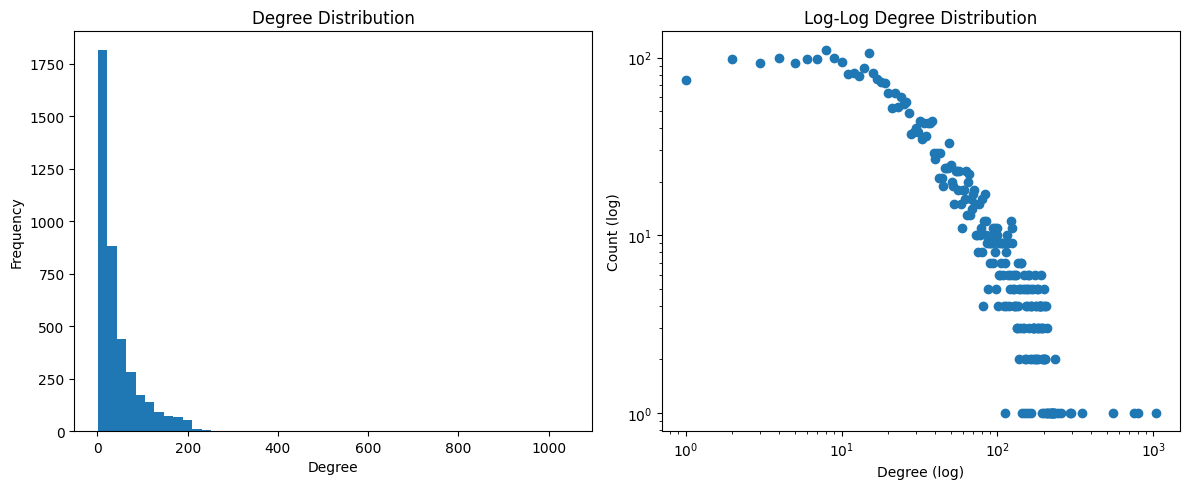

In [69]:
deg, cnt = zip(*sorted(degree_counts.items()))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.scatter(deg, cnt)
plt.xscale("log")
plt.yscale("log")
plt.title("Log-Log Degree Distribution")
plt.xlabel("Degree (log)")
plt.ylabel("Count (log)")

plt.tight_layout()
plt.show()

### Path Length and Clustering Analysis
This section evaluates the structural properties of the network, including path efficiency and clustering behaviour.

The average shortest path length is relatively small, indicating that nodes in the network are closely connected. The diameter is also low, suggesting that the maximum distance between any two nodes is limited.

The clustering coefficient is high, indicating a strong tendency for nodes to form tightly connected groups. This reflects the typical structure of social networks, where users tend to form communities.

In [70]:
avg_path = nx.average_shortest_path_length(G_lcc)
diameter = nx.diameter(G_lcc)
avg_clustering = nx.average_clustering(G_lcc)
transitivity = nx.transitivity(G_lcc)

print("Average shortest path length:", round(avg_path, 4))
print("Diameter:", diameter)
print("Average clustering coefficient:", round(avg_clustering, 4))
print("Transitivity:", round(transitivity, 4))
print("density:",round(density, 6))

Average shortest path length: 3.6925
Diameter: 8
Average clustering coefficient: 0.6055
Transitivity: 0.5192
density: 0.01082


### Centrality tables
 Here the top-ranked nodes are summarised below for the main centrality measures.

In [71]:
deg_cent = nx.degree_centrality(G_lcc)
close_cent = nx.closeness_centrality(G_lcc)
between_cent = nx.betweenness_centrality(G_lcc, k=200, seed=42)

top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_close = sorted(close_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_between = sorted(between_cent.items(), key=lambda x: x[1], reverse=True)[:5]



In [72]:
print("Top nodes by degree centrality:", top_deg)
print("Top nodes by closeness centrality:", top_close)
print("Top nodes by betweenness centrality:", top_between)

Top nodes by degree centrality: [(107, 0.258791480931154), (1684, 0.1961367013372957), (1912, 0.18697374938088163), (3437, 0.13546310054482416), (0, 0.08593363051015354)]
Top nodes by closeness centrality: [(107, 0.45969945355191255), (58, 0.3974018305284913), (428, 0.3948371956585509), (563, 0.3939127889961955), (1684, 0.39360561458231796)]
Top nodes by betweenness centrality: [(107, 0.49067517131504973), (1684, 0.36069573820421513), (1912, 0.22612213264683975), (3437, 0.21424786820064665), (0, 0.14737680524496516)]


In [73]:
top_deg_df = pd.DataFrame(top_deg, columns=["Node", "Degree Centrality"])
top_deg_df

,Node,Degree Centrality
0,107,0.258791
1,1684,0.196137
2,1912,0.186974
3,3437,0.135463
4,0,0.085934


### Network Visualisation
here is a the network is visualised to illustrate its structure.

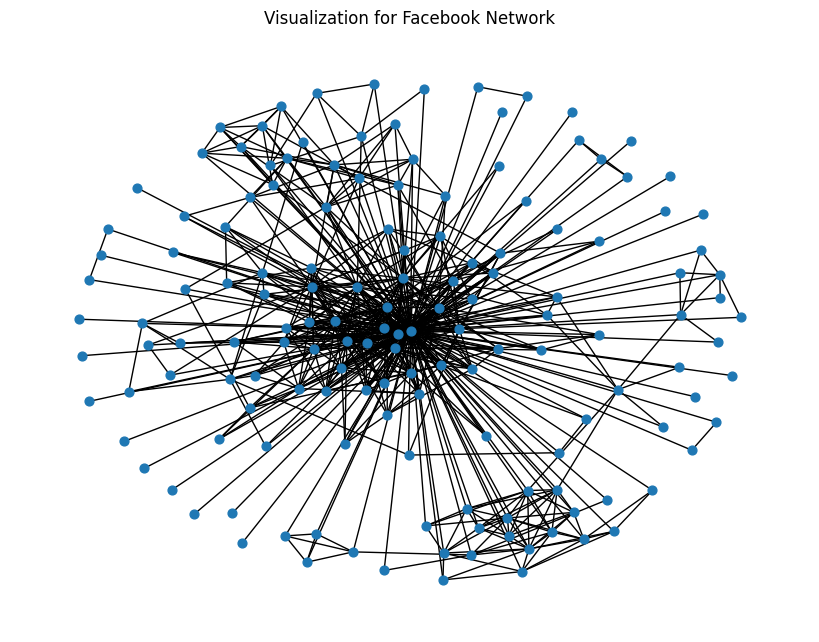

In [74]:
nodes = list(G_lcc.nodes())[:150]
subgraph = G_lcc.subgraph(nodes)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(subgraph, seed=42)

nx.draw(subgraph, pos, node_size=40)

plt.title("Visualization for Facebook Network")
plt.show()

#Comparison with ER, BA, and WS models

In [75]:
n = G_lcc.number_of_nodes()
m = G_lcc.number_of_edges()
avg_degree = int((2 * m) / n)

In [76]:
p = (2 * m) / (n * (n - 1))
G_er = nx.erdos_renyi_graph(n, p, seed=42)

ba_m = max(1, avg_degree // 2)
G_ba = nx.barabasi_albert_graph(n, ba_m, seed=42)

k_ws = avg_degree if avg_degree % 2 == 0 else avg_degree + 1
G_ws = nx.watts_strogatz_graph(n, k_ws, 0.1, seed=42)

In [77]:
def metrics(G, name):
    if not nx.is_connected(G):
        Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    else:
        Gc = G

    return {
        "Graph": name,
        "Nodes": G.number_of_nodes(),
        "Edges": G.number_of_edges(),
        "Density": nx.density(G),
        "Clustering": nx.average_clustering(G),
        "Components": nx.number_connected_components(G),
        "Path Length": nx.average_shortest_path_length(Gc),
        "Diameter": nx.diameter(Gc),
        "Avg Degree": sum(dict(G.degree()).values()) / G.number_of_nodes()
    }

### Comparison with Network Models
The real Facebook network is compared with three classical network models: Erdős–Rényi (random), Barabási–Albert (scale-free), and Watts–Strogatz (small-world).

At the end here the results show that the Facebook network differs significantly from the random graph, particularly in its higher clustering and structured connectivity. The Barabási–Albert model more closely reflects the presence of highly connected nodes, indicating a scale-free structure. The Watts–Strogatz model captures some clustering but does not fully replicate the network's degree distribution. Overall, the Facebook network exhibits characteristics of both small-world and scale-free networks.

In [78]:
import pandas as pd

data = [
    metrics(G_lcc, "Facebook"),
    metrics(G_er, "Erdos-Renyi"),
    metrics(G_ba, "Barabasi-Albert"),
    metrics(G_ws, "Watts-Strogatz")
]

df = pd.DataFrame(data)
df

,Graph,Nodes,Edges,Density,Clustering,Components,Path Length,Diameter,Avg Degree
0,Facebook,4039,88234,0.010820,0.605547,1,3.692507,8,43.691013
1,Erdos-Renyi,4039,87553,0.010736,0.010766,1,2.610505,4,43.353800
2,Barabasi-Albert,4039,84378,0.010347,0.035159,1,2.540807,4,41.781629
3,Watts-Strogatz,4039,88858,0.010896,0.534717,1,2.964702,4,44.000000


### Degree Distribution Comparison
here i compare again the  degree distributions of the real network and the generated models using histograms.

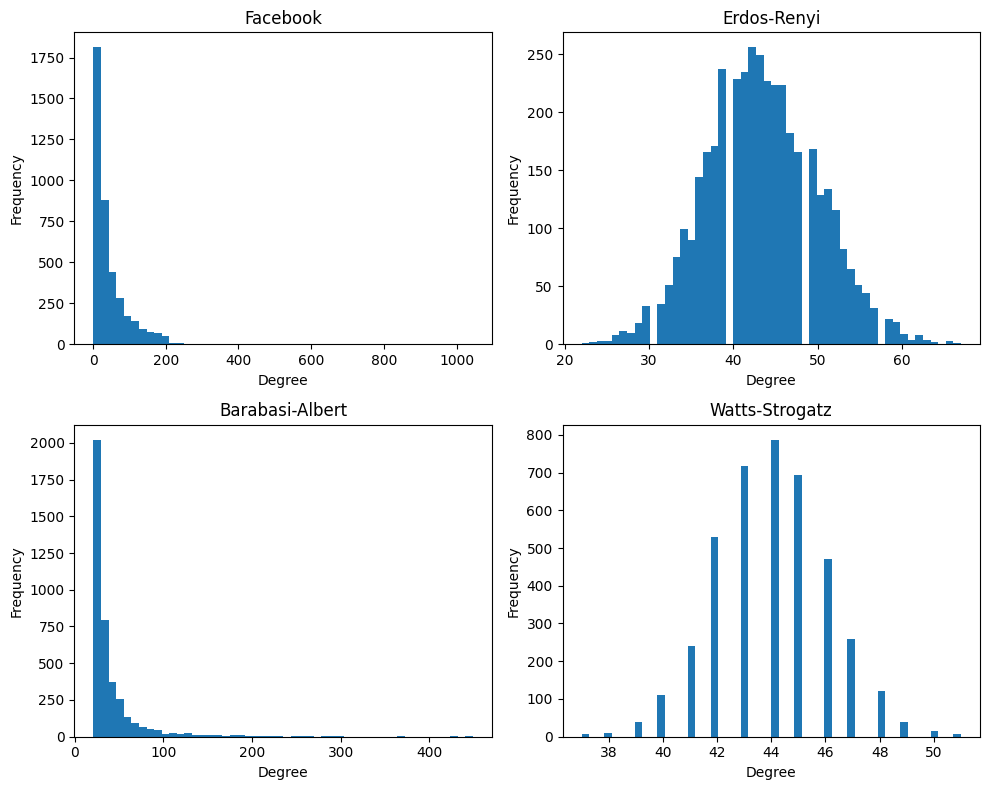

In [79]:
plt.figure(figsize=(10,8))

graphs = [G_lcc, G_er, G_ba, G_ws]
titles = ["Facebook", "Erdos-Renyi", "Barabasi-Albert", "Watts-Strogatz"]

for i, (graph, title) in enumerate(zip(graphs, titles), 1):
    plt.subplot(2, 2, i)
    degrees = [d for _, d in graph.degree()]
    plt.hist(degrees, bins=50)
    plt.title(title)
    plt.xlabel("Degree")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### in Conclusion
The analysis demonstrates that the Facebook network exhibits properties of both scale-free and small-world networks. The presence of highly connected nodes and a skewed degree distribution aligns with the Barabási–Albert model, while the relatively high clustering suggests small-world characteristics similar to the Watts–Strogatz model. In contrast, the Erdős–Rényi model fails to capture these structural features, highlighting the non-random nature of real-world social networks.